## 1. An Overview Kernel Gradient Discrepancy (KGD)

KGD measures the pairwise alignment of the residual WGF vector field across particles, with nearby particles contributing more strongly (usually) through the kernel weighting.

The Wasserstein gradient of the entropy-regularised objective $J(Q) = \lambda_n \frac{1}{n} \sum_{i=1}^{n} S(P_Q, x_i) + D_{\text{KL}}(Q \parallel Q_0)$ defines the velocity field:

$$\nabla_{\vartheta} \mathcal{J}(Q)(\vartheta) = \underbrace{\frac{\lambda_n}{n} \sum_{i=1}^{n} \nabla_\vartheta \left( \frac{\delta S(P_Q, x_i)}{\delta q(\vartheta)} \right)}_{\text{Predictive Data-fit Gradient}} + \underbrace{ \nabla_\vartheta\log q(\vartheta) - \nabla_\vartheta\log\pi(\vartheta) }_{\text{KL Divergence Gradient}}$$

If the swarm has reached the optimal equilibrium, this gradient should be zero everywhere. However, because we are using discrete particles, the continuous density $q$ is unknown, making the entropy term $\nabla_\vartheta \log q(\vartheta)$ impossible to compute directly.

Because we cannot compute the true gradient directly, we measure it indirectly. We introduce an arbitrary smooth "test" vector field $f(\vartheta)$ from a Reproducing Kernel Hilbert Space (RKHS) and measure how strongly our true gradient aligns with it. By taking the expected alignment over our distribution $Q$, we can rely on Stein’s Identity. Assuming the density $q$ vanishes at the boundaries of the domain, we can use integration by parts to shift the spatial derivative off of the intractable density and onto our chosen test field $f$:

Let $\frac{\lambda_n}{n} \sum_{i=1}^{n} \nabla_\vartheta \left( \frac{\delta S(P_Q, x_i)}{\delta q(\vartheta)} \right) =\nabla_{\vartheta} \mathcal{L}(Q)(\vartheta)$.

$$\int \nabla_{\vartheta} \mathcal{J}(Q)(\vartheta) \cdot f(\vartheta) \, dQ(\vartheta)$$
$$= \int \left[ \nabla_{\vartheta} \mathcal{L}(Q)(\vartheta) - (\nabla \log \pi)(\vartheta)  \right]\cdot f(\vartheta) dQ(\vartheta) + \int \left( \nabla \log q \right)(\vartheta) \cdot f(\vartheta) \, dQ(\vartheta)$$
$$= \int \left[ \nabla_{\vartheta} \mathcal{L}(Q)(\vartheta) - (\nabla \log \pi)(\vartheta) \right]\cdot f(\vartheta) dQ(\vartheta) - \int (\nabla \cdot f)(\vartheta) dQ(\vartheta)$$
$$= - \int \mathcal{T}_{Q} f(\vartheta) \, dQ(\vartheta).$$

By grouping this resulting negative divergence term with the deterministic drift terms from the loss and prior, we arrive exactly at the definition of the negative Variational Stein Operator, $-T_Q f(\vartheta)$. This mathematical maneuver is the entire reason Kernel Gradient Discrepancy is computable without knowing the continuous density of the particle swarm.

This transformation is formalized by the Variational Stein Operator ($\mathcal{T}_Q$). For an arbitrary RKHS vector field $f(\vartheta)$:

$$\mathcal{T}_{Q, \vartheta} f(\vartheta) = \nabla_\vartheta \cdot f(\vartheta) - f(\vartheta)^T b(\vartheta, Q)$$

Notice that the operator evaluates the vector field entirely using the known drift $b(\vartheta, Q) = \frac{\lambda_n}{n} \sum_{i=1}^{n} \nabla_\vartheta \left( \frac{\delta S(P_Q, x_i)}{\delta q(\vartheta)} \right) - \nabla_\vartheta\log\pi(\vartheta)$ and the spatial divergence $\nabla_\vartheta \cdot f(\vartheta)$, completely eliminating $\log q$ from the computation.

KGD is formally defined by finding the "worst-case" test field $f$ in the RKHS unit ball that maximizes this computable alignment (a Stein discrepancy):

$$\mathrm{KGD}_{\mathcal K}(Q) = \sup_{\substack{f\in\mathcal B_{\mathcal K}\\\mathcal T_Q f\in L^1(Q)}}\left\vert{}\int \mathcal T_Q f(\vartheta)\,dQ(\vartheta)\right\vert{}.$$

Therefore, the supremum is perfectly solved and reduces KGD to the norm of this projected vector field:

$$\mathrm{KGD}(Q)=\vert{}\vert{}v_Q\vert{}\vert{}_{\mathcal H_K}.$$

We can express this squared norm as a double expectation over the distribution $Q$:

$$\mathrm{KGD}^2(Q)=\iint v_Q(\vartheta)^TK(\vartheta,\vartheta')v_Q(\vartheta')\,dQ(\vartheta)dQ(\vartheta').$$


To compute this without explicitly constructing $v_Q$, we apply the Variational Stein operator to our kernel twice which creates the Stein Kernel, $h_Q(\vartheta, \vartheta')$:
$$h_Q(\vartheta, \vartheta') = \mathcal{T}_{Q, \vartheta} \mathcal{T}_{Q, \vartheta'} K(\vartheta, \vartheta')$$

Applying these operators to our kernel results in:

1. The Base Interaction: $b_Q(\vartheta)^T K(\vartheta, \vartheta') b_Q(\vartheta')$
   *(Evaluates the alignment of deterministic forces between particles)*
2. Cross Term 1: $b_Q(\vartheta)^T \nabla_{\vartheta'} K(\vartheta, \vartheta')$
   *(Cross-interaction between force and spatial geometry)*
3. Cross Term 2: $\nabla_\vartheta K(\vartheta, \vartheta')^T b_Q(\vartheta')$
   *(Symmetric cross-interaction)*
4. The Trace Term $\mathrm{Tr}\big( \nabla_\vartheta \nabla_{\vartheta'} K(\vartheta, \vartheta') \big)$
   *(The divergence of a gradient is the trace of the Hessian; this term strictly penalizes the collapse of the swarm, acting as the proxy for our missing entropy).*

$$h_Q(\vartheta, \vartheta') = b_Q(\vartheta)^T K(\vartheta, \vartheta') b_Q(\vartheta') - b_Q(\vartheta)^T \nabla_{\vartheta'} K(\vartheta, \vartheta') - \nabla_\vartheta K(\vartheta, \vartheta')^T b_Q(\vartheta') + \mathrm{Tr}\big( \nabla_\vartheta \nabla_{\vartheta'} K(\vartheta, \vartheta') \big)$$

Transitioning from the continuous distribution $Q$ to our empirical particle swarm $Q_n$, the double expectation integral becomes a double summation over all $N_p$ pairwise particle interactions. This yields the exact, fully computable equation utilized in our implementation:

$$\mathrm{KGD}^2(Q_n) = \frac{1}{N_p^2} \sum_{j=1}^{N_p} \sum_{l=1}^{N_p} h_{Q_n}(\vartheta^{(j)}, \vartheta^{(l)})$$


## 2. Implementing KGD

The beauty of evaluating KGD within `pymc-prop` is that the most computationally expensive operations, evaluating the log-score gradients across the dataset and the prior, are already handled natively inside the Wasserstein Gradient Flow (WGF) loop.

$b(Q, \vartheta)$ is currently calculated by the `scaled_drift` function, when isolating the variational gradient vector $b(Q, \vartheta)$ from this time_step() update, we must extract only the net deterministic drift, the combination of the prior pull and the data-fit score scaled by $\lambda_n$. We explicitly exclude both the numerical integration step_size and the injected Brownian noise. Excluding step_size ensures KGD remains a continuous-time metric that serves as an absolute, step-size-independent stopping criterion, while omitting Brownian noise prevents stochastic variance from obscuring the smooth convergence of our diagnostic to zero.

With the pure drift tensor (shape `N_p, d`) isolated, computing KGD requires only three steps:
1. Extract the raw `drift` and `particles` tensors at a given time step.
2. Define a positive-definite RKHS kernel to measure the spatial correlation of the particles.
3. Compute the double sum estimator of the kernelized forces efficiently.

In [4]:
import numpy as np
import pymc as pm
import arviz as az
import matplotlib.pyplot as plt

# Internal building blocks mapping to the pymc_prop structure
from pymc_prop.fuse import FuseState, fuse_step_size
from pymc_prop.particles import initialize_particles, scaled_drift, time_step
from pymc_prop.points import make_point_mapper
from pymc_prop.scoring import LogScore

az.style.use("arviz-variat")

Below is the RBF (Gaussian) Kernel implementation including the Median Heuristic calculation along with the overarching KGD compute function.

In [5]:
def compute_kgd(particles: np.ndarray, forces: np.ndarray, lengthscale: float | None = None) -> float:
    """
    Computes the full 4-term Kernel Gradient Discrepancy (KGD^2) estimator 
    using an RBF kernel and Stein's Identity.
    """
    N, d = particles.shape
    
    # 1. Pairwise differences and squared distances
    # diffs shape: (N, N, d) -> diffs[j, l] = x_j - x_l
    diffs = particles[:, None, :] - particles[None, :, :]  
    sq_dists = np.sum(diffs ** 2, axis=-1)                 
    
    # 2. Bandwidth (Median Heuristic)
    if lengthscale is None:
        off_diag = sq_dists[np.triu_indices(N, k=1)]
        median_sq = np.median(off_diag) if off_diag.size else 0.0
        bandwidth = median_sq / np.log(N) if median_sq > 0 else 1.0
        bandwidth = max(bandwidth, 1e-12)
    else:
        bandwidth = max(lengthscale ** 2, 1e-12)
        
    # 3. RBF Kernel Matrix
    K = np.exp(-sq_dists / bandwidth)
    
    # 4. Term 1: Base Interaction b(x)^T K(x,y) b(y)
    # The dot product (forces @ forces.T) creates an (N, N) matrix of b_j^T b_l
    term1 = (forces @ forces.T) * K 
    
    # 5. Terms 2 & 3: The Cross Terms
    # 2/h * K(x,y) * (b(x) - b(y))^T (x - y)
    force_diffs = forces[:, None, :] - forces[None, :, :]
    cross_dot = np.sum(force_diffs * diffs, axis=-1)
    term23 = (2.0 / bandwidth) * K * cross_dot
    
    # 6. Term 4: The Trace Term
    # Tr(\nabla_x \nabla_y K(x,y))
    term4 = K * ((2.0 * d / bandwidth) - (4.0 / (bandwidth ** 2)) * sq_dists)
    
    # 7. Final KGD^2 Expectation
    kgd_sq = np.sum(term1 + term23 + term4) / (N ** 2)
    
    # Guard against tiny numerical precision artifacts dropping below exactly 0
    return float(max(kgd_sq, 0.0))

This is what it could look like when added to the main sample function (with a lot of generality simplified for the demo).

In [6]:
def sample_pro_with_kgd(
    model=None,
    n_particles: int = 40,
    n_steps: int = 1000,
    tune: int = 200,
    step_size: float | None = None,
    learning_rate: float = 1.0,
    lengthscale: float | None = None,
    kgd_compute_every: int = 10,
    r_eps: float = 1e-5,
    random_seed: int | None = None,
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
    Run the log-score PrO sampler while tracking KGD. 
    KGD is computed periodically to save O(N^2) overhead.
    """
    model = pm.modelcontext(model)
    if n_particles < 2:
        raise ValueError("n_particles must be at least 2.")

    mapper = make_point_mapper(model)
    drift_fn = LogScore().compile_drift(model, mapper)

    rng = np.random.default_rng(random_seed)
    particles = initialize_particles(model, mapper, n_particles, rng)

    use_fuse = step_size is None
    fuse_state: FuseState | None = None
    current_step_size = step_size

    particles_history = []
    kgd_history = []
    kgd_steps = []

    for step in range(tune + n_steps):
        wgf_grad, prior_grad = drift_fn(particles)

        if use_fuse:
            current_step_size, fuse_state, _diag = fuse_step_size(
                particles, wgf_grad, prior_grad, learning_rate, fuse_state, r_eps
            )

        if step >= tune:
            # We only track history and compute KGD on intervals to reduce computational overhead
            if (step - tune) % kgd_compute_every == 0:
                kgd_val = compute_kgd(particles, scaled_drift(wgf_grad, prior_grad, learning_rate), lengthscale=lengthscale)
                kgd_history.append(kgd_val)
                kgd_steps.append(step - tune)
                particles_history.append(particles.copy())

        particles = time_step(particles, prior_grad, wgf_grad, current_step_size, learning_rate, rng)

    return (
        np.stack(particles_history, axis=0), 
        np.asarray(kgd_history, dtype=float), 
        np.asarray(kgd_steps, dtype=int)
    )

--- Running KGD Experiment ---
Steps: 1500 | Step Size: FUSE | Lengthscale: Median Heuristic


C:\Users\patri\AppData\Local\Temp\ipykernel_24184\2259654890.py:55: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


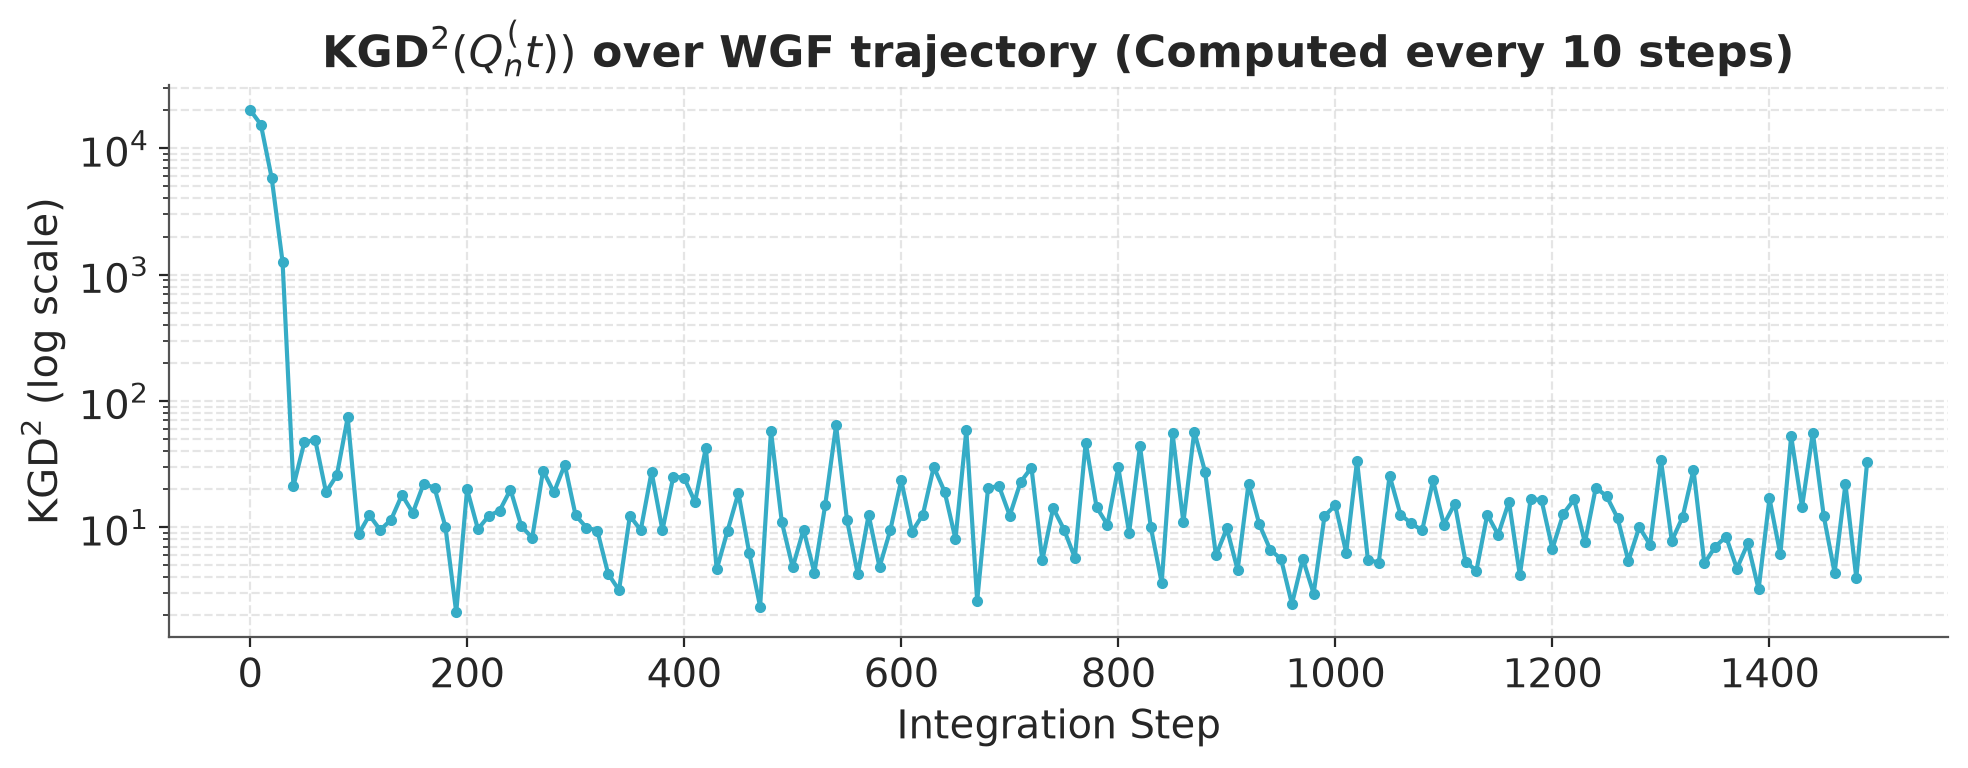

In [7]:
def run_kgd_experiment(
    n_particles=40,
    n_steps=1500,
    step_size=None,
    lengthscale=None,
    kgd_compute_every=10,
    seed=2026
):
    """
    Sets up a 1D Gaussian Mixture Model target and runs the KGD diagnostic suite.
    Allows for testing the impact of fixed step sizes vs. fuse heuristics, and 
    fixed lengthscales vs. the median heuristic.
    """
    print(f"--- Running KGD Experiment ---")
    print(f"Steps: {n_steps} | Step Size: {'FUSE' if step_size is None else step_size} | "
          f"Lengthscale: {'Median Heuristic' if lengthscale is None else lengthscale}")
    
    # 1. Generate Synthetic Data
    N = 300
    sigma = 0.7
    component_means = np.array([-1.5, 2.25])
    component_weights = np.array([0.4, 0.6])
    rng = np.random.default_rng(seed)
    
    components = rng.choice(len(component_means), size=N, p=component_weights)
    y = rng.normal(loc=component_means[components], scale=sigma)

    # 2. Define PyMC Model
    with pm.Model() as model:
        mu = pm.Normal("mu", mu=0.0, sigma=1.0)
        pm.Normal("y", mu=mu, sigma=sigma, observed=y)

        particles_history, kgd_history, kgd_steps = sample_pro_with_kgd(
            model=model,
            n_particles=n_particles,
            n_steps=n_steps,
            step_size=step_size,
            lengthscale=lengthscale,
            kgd_compute_every=kgd_compute_every,
            r_eps=1e-5,
            tune=0,
            random_seed=seed,
        )
        
    # 3. Plotting Diagnostics
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(kgd_steps, kgd_history, color="C0", lw=1.5, marker="o", markersize=3)
    ax.set_yscale("log")
    ax.set(
        title=f"KGD$^2(Q_n^(t))$ over WGF trajectory (Computed every {kgd_compute_every} steps)",
        xlabel="Integration Step",
        ylabel="KGD$^2$ (log scale)",
    )
    ax.grid(True, which="both", ls="--", alpha=0.5)
    plt.tight_layout()
    plt.show()

# Run Default Test: FUSE step size and Median Heuristic lengthscale
run_kgd_experiment()